<a href="https://colab.research.google.com/github/srabani-khuntia/LLM_Using_Python/blob/main/1st_2nd_June.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Creating Application Using LLM Models**

# Importing Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras # importing sub packages
from tensorflow.keras import layers # imoprting sub packages

import tensorflow_datasets as tfds

# Data Reading and analysis

In [10]:
tfds.list_builders() #view the current datasets provided by TF

['abstract_reasoning',
 'accentdb',
 'aeslc',
 'aflw2k3d',
 'ag_news_subset',
 'ai2_arc',
 'ai2_arc_with_ir',
 'ai2dcaption',
 'aloha_mobile',
 'amazon_us_reviews',
 'anli',
 'answer_equivalence',
 'arc',
 'asimov_dilemmas_auto_val',
 'asimov_dilemmas_scifi_train',
 'asimov_dilemmas_scifi_val',
 'asimov_injury_val',
 'asimov_multimodal_auto_val',
 'asimov_multimodal_manual_val',
 'asimov_v2_constraints_with_rationale',
 'asimov_v2_constraints_without_rationale',
 'asimov_v2_injuries',
 'asimov_v2_videos',
 'asqa',
 'asset',
 'assin2',
 'asu_table_top_converted_externally_to_rlds',
 'austin_buds_dataset_converted_externally_to_rlds',
 'austin_sailor_dataset_converted_externally_to_rlds',
 'austin_sirius_dataset_converted_externally_to_rlds',
 'bair_robot_pushing_small',
 'bc_z',
 'bccd',
 'beans',
 'bee_dataset',
 'beir',
 'berkeley_autolab_ur5',
 'berkeley_cable_routing',
 'berkeley_fanuc_manipulation',
 'berkeley_gnm_cory_hall',
 'berkeley_gnm_recon',
 'berkeley_gnm_sac_son',
 'berkel

In [2]:
train_split, valid_split = ['train[:90%]', 'train[90%:]']

#Get training Data
train_data, info = tfds.load('cifar10', split=train_split, with_info=True)

#Get valid data
valid_data = tfds.load('cifar10', split=valid_split)

#Get test data
test_data = tfds.load('cifar10', split=tfds.Split.TEST)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.Y9YYOP_3.0.2/cifar10-train.tfrecord-[0-9][0-9][0-9][0-9…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.Y9YYOP_3.0.2/cifar10-test.tfrecord-[0-9][0-9][0-9][0-9]…

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


In [ ]:
# Dispay CIFAR10 information
print(info)

tfds.core.DatasetInfo(
    name='cifar10',
    full_name='cifar10/3.0.2',
    description="""
    The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.
    """,
    homepage='https://www.cs.toronto.edu/~kriz/cifar.html',
    data_dir='/root/tensorflow_datasets/cifar10/3.0.2',
    file_format=tfrecord,
    download_size=162.17 MiB,
    dataset_size=132.40 MiB,
    features=FeaturesDict({
        'id': Text(shape=(), dtype=string),
        'image': Image(shape=(32, 32, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=50000, num_shards=1>,
    },
    citation="""@TECHREPORT{Krizhevsky09learningmultiple,
        author = {Alex Kr

In [11]:
# 10 classes of CIFAR10

labels_dict = dict(enumerate(info.features['label'].names))
labels_dict

{0: 'airplane',
 1: 'automobile',
 2: 'bird',
 3: 'cat',
 4: 'deer',
 5: 'dog',
 6: 'frog',
 7: 'horse',
 8: 'ship',
 9: 'truck'}

In [12]:
# Create a dictionary to count the number of tags in each category
train_dict = {}

# Read the entire training dataset
for data in train_data:
    #Convert the read label to numpy format
    label = data['label'].numpy()

    # Count the number of each category : use a dictionary
    train_dict[label] = train_dict.setdefault(label,0) + 1
train_dict

{np.int64(1): 4508,
 np.int64(2): 4522,
 np.int64(7): 4500,
 np.int64(0): 4530,
 np.int64(6): 4505,
 np.int64(5): 4503,
 np.int64(8): 4456,
 np.int64(3): 4526,
 np.int64(4): 4497,
 np.int64(9): 4453}

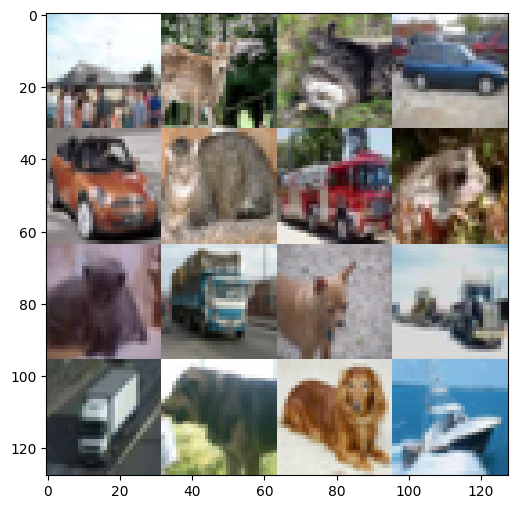

In [13]:
# Create an array to display images
output = np.zeros((32*4, 32*4, 3), dtype = np.uint8)
row = 0

for data in train_data.batch(4).take(4):
  output[:, row*32:(row+1)*32] = np.vstack(data['image'].numpy())
  row+=1

# Set the display window size
plt.figure(figsize=(6,6))

# Dislay image
plt.imshow(output)

# Data Division:
Converting Data:


* Normalisation,
* Label Data





In [14]:
def parse_fn(dataset):
  # image standardization
  x = tf.cast(dataset['image'], tf.float32) / 255.0
  # Convert the output label to One Hot Encoding
  y = tf.one_hot(dataset['label'], 10)
  return x, y

In [15]:
# Setting training data, validation data and test data

AUTOTUNE = tf.data.experimental.AUTOTUNE # Automatic adjustment role
batch_size = 64 #Batch size
train_num = int(info.splits['train'].num_examples/10) * 9 #Number of training

# Shuffle the training data
train_data = train_data.shuffle(train_num)

# Training data
train_data = train_data.map(map_func = parse_fn, num_parallel_calls=AUTOTUNE)

# Set the batch size to 64 and turn on prefetch mode
train_data = train_data.batch(batch_size).prefetch(buffer_size = AUTOTUNE)

# Validation Data
valid_data = valid_data.map(map_func = parse_fn, num_parallel_calls=AUTOTUNE)

# Set the batch size to 64 and turn on prefetch mode
valid_data = valid_data.batch(batch_size).prefetch(buffer_size = AUTOTUNE)

# Test Data
test_data = test_data.map(map_func = parse_fn, num_parallel_calls=AUTOTUNE)

# Set the batch size to 64 and turn on prefetch mode
test_data = test_data.batch(batch_size).prefetch(buffer_size = AUTOTUNE)


TypeError: in user code:


    TypeError: outer_factory.<locals>.inner_factory.<locals>.tf__parse_fn() takes 1 positional argument but 2 were given


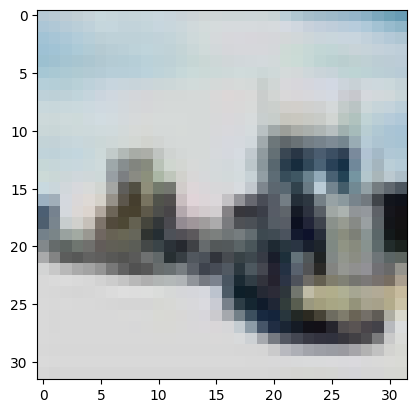

In [16]:
x = 3
y = 2

#Read image
image_test = output[y*32 : (y+1)*32, x*32 : (x+1)*32, : ]

#Display image
plt.imshow(image_test)

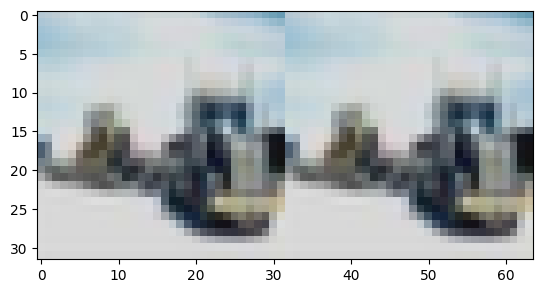

In [17]:
# Flip horizontally

def flip(x):
  #flip image

  x = tf.image.random_flip_left_right(x)  #Randomly flip the image
  return x

image_2 = flip(image_test)
image = np.hstack((image_test, image_2))

#Display image
plt.imshow(image)

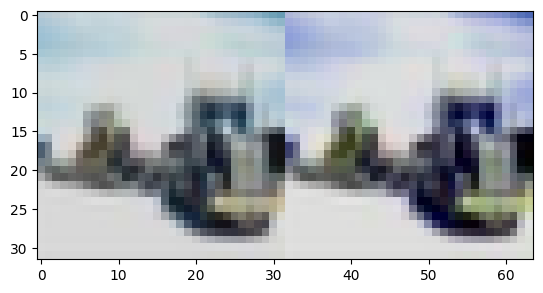

In [18]:
def color(x):

  # Color Conversion

  x = tf.image.random_hue(x, 0.08)
  x = tf.image.random_saturation(x, 0.6, 1.6)
  x = tf.image.random_brightness(x, 0.05)
  x = tf.image.random_contrast(x, 0.7, 1.3)

  return x
image_2 = color(image_test)
image = np.hstack((image_test, image_2))

#Display image
plt.imshow(image)


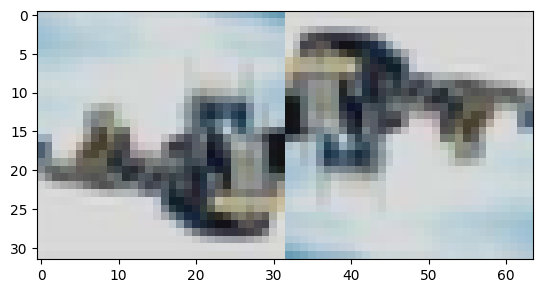

In [19]:
#Image Rotation
def rotate(x):
  x = tf.image.rot90(x, tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
  return x

image_2 = rotate(image_test)
image = np.hstack((image_test, image_2))

#Display image
plt.imshow(image)


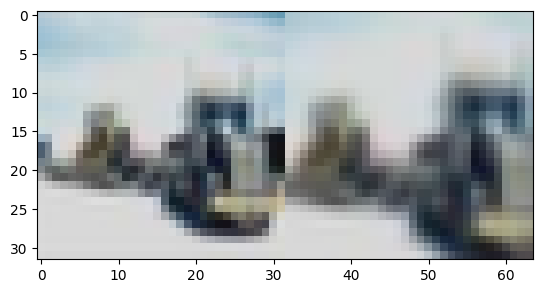

In [20]:
# Zoom
def zoom(x):
  h, w, c = x.shape
  scale_min = 0.6  # Define minimum scale for zooming
  scale_max = 1.4  # Define maximum scale for zooming
  scale = tf.random.uniform([], scale_min, scale_max)
  sh = h * scale #height of image after zooming
  sw = w * scale #width of image after zooming

  x = tf.image.resize(x, (tf.cast(sh, tf.int32), tf.cast(sw, tf.int32))) #resize
  x = tf.image.resize_with_crop_or_pad(x, h, w)
  return x

# Convert image_test to float32 and scale to 0-1 for consistent processing
image_test_scaled = tf.cast(image_test, tf.float32) / 255.0

image_2_scaled = zoom(image_test_scaled)
image_display = np.hstack((image_test_scaled, image_2_scaled))

#Display image
plt.imshow(image_display)

In [21]:
train_data = tfds.load('cifar10', split=train_split)

In [22]:
# Image Augmentation function

def parse(dataset):
  x = tf.cast(dataset['image'], tf.float32)/255 #Image standardization
  x = flip(x) #Random horizontal flip

  #Color conversion
  x = tf.cond(tf.random.uniform([], 0, 1) > 0.5, lambda: color(x), lambda: x)

  #Image rotation
  x = tf.cond(tf.random.uniform([], 0, 1) > 0.75, lambda: rotate(x), lambda: x)

  #Image zoom
  x = tf.cond(tf.random.uniform([], 0, 1) > 0.5, lambda: zoom(x), lambda: x)

  #Convert the output label to One-Hot encoding
  y = tf.one_hot(dataset['label'], 10)
  return x, y


In [23]:
# Shuffle data
train_data = train_data.shuffle(train_num)

#Loading data
train_data = train_data.map(map_func=parse, num_parallel_calls=AUTOTUNE)

# Set the batch size to 64 and turn on prefetch mode
train_data = train_data.batch(batch_size).prefetch(buffer_size = AUTOTUNE)

In [24]:
for images, labels in train_data.take(1):
  images = images.numpy()

#Create an array to display images
output = np.zeros((32*8, 32*8, 3))

#Add 64 data into the array for displaying images
for i in range(8):
  for j in range(8):
    output[i*32:(i+1)*32, j*32:(j+1)*32, :] = images[i*8+j]

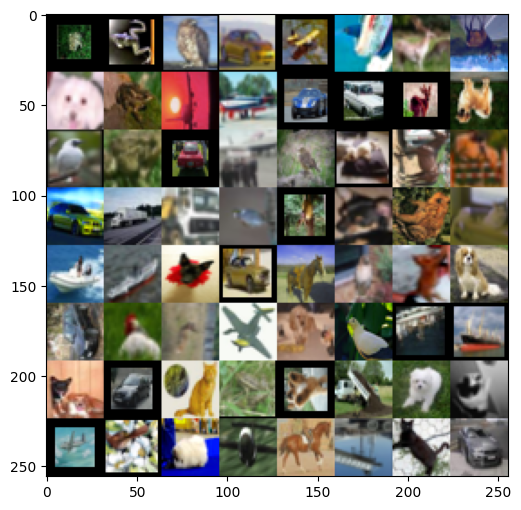

In [25]:
#Set the display window size
plt.figure(figsize=(6,6))

#Display image
plt.imshow(output)

### Model-1

In [44]:
inputs = keras.Input(shape=(32,32,3))
x = layers.Flatten()(inputs)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)

x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

#Create a network model
model_1 = keras.Model(inputs, outputs, name = 'model-1')
model_1.summary() #Shows network architecture

#model_dir = 'lab4-logs/models/'
#os.makedirs(model_dir)

Model: "model-1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 969,034 (3.70 MB)

 Trainable params: 969,034 (3.70 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
#Save training records as TensorBoard of files
log_dir = os.path.join('lab4-logs', 'model-1')
model_cbk = keras.callbacks.TensorBoard(log_dir = log_dir)

#Save the best model
model_mckp = keras.callbacks.ModelCheckpoint(model_dir + '/Best-model-1.h5',
                                            monitor = 'val_categorical_accuracy',
                                            save_best_only = True,
                                            mode = 'max')

In [46]:
model_1.compile(keras.optimizers.Adam(),
                loss = keras.losses.CategoricalCrossentropy(),
                metrics = [keras.metrics.CategoricalAccuracy()])

In [47]:
history_1 = model_1.fit(train_data,
                        epochs = 100,
                        validation_data = valid_data,
                        callbacks = [model_cbk, model_mckp])

Epoch 1/100
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - categorical_accuracy: 0.1648 - loss: 2.1732

704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - categorical_accuracy: 0.1922 - loss: 2.1139 - val_categorical_accuracy: 0.2742 - val_loss: 1.9619
Epoch 2/100
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - categorical_accuracy: 0.2546 - loss: 2.0184

704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - categorical_accuracy: 0.2680 - loss: 1.9929 - val_categorical_accuracy: 0.3448 - val_loss: 1.8227
Epoch 3/100
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - categorical_accuracy: 0.2919 - loss: 1.9519

704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - categorical_accuracy: 0.2934 - loss: 1.9424 - val_categorical_accuracy: 0.3648 - val_loss: 1.7737
Epoch 4/100
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - categorical_accuracy: 0.3045 - loss: 1.9176

704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - categorical_accuracy: 0.3069 - loss: 1.9150 - val_categorical_accuracy: 0.3674 - val_loss: 1.7941
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - categorical_accuracy: 0.3172 - loss: 1.8965 - val_categorical_accuracy: 0.3594 - val_loss: 1.7702
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - categorical_accuracy: 0.3209 - loss: 1.8883

...

704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - categorical_accuracy: 0.4088 - loss: 1.6710 - val_categorical_accuracy: 0.4574 - val_loss: 1.5443
Epoch 57/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - categorical_accuracy: 0.4072 - loss: 1.6798 - val_categorical_accuracy: 0.4468 - val_loss: 1.5557
Epoch 58/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - categorical_accuracy: 0.4098 - loss: 1.6730 - val_categorical_accuracy: 0.4462 - val_loss: 1.5436
Epoch 59/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - categorical_accuracy: 0.4130 - loss: 1.6635 - val_categorical_accuracy: 0.4524 - val_loss: 1.5232
Epoch 60/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - categorical_accuracy: 0.4129 - loss: 1.6626 - val_categorical_accuracy: 0.4490 - val_loss: 1.5672
Epoch 61/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - categorical_accuracy: 0.4111 - loss: 1.6672 - val_categorical_accuracy: 0.4492 - val_loss: 1.5375
Epoch 62/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - categorical_accurac

704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - categorical_accuracy: 0.4128 - loss: 1.6594 - val_categorical_accuracy: 0.4628 - val_loss: 1.5278
Epoch 65/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - categorical_accuracy: 0.4151 - loss: 1.6578 - val_categorical_accuracy: 0.4526 - val_loss: 1.5343
Epoch 66/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - categorical_accuracy: 0.4142 - loss: 1.6569 - val_categorical_accuracy: 0.4484 - val_loss: 1.5551
Epoch 67/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - categorical_accuracy: 0.4126 - loss: 1.6619 - val_categorical_accuracy: 0.4486 - val_loss: 1.5461
Epoch 68/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - categorical_accuracy: 0.4134 - loss: 1.6533 - val_categorical_accuracy: 0.4528 - val_loss: 1.5228
Epoch 69/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - categorical_accuracy: 0.4173 - loss: 1.6531 - val_categorical_accuracy: 0.4566 - val_loss: 1.5237
Epoch 70/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - categorical_accurac

704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - categorical_accuracy: 0.4186 - loss: 1.6508 - val_categorical_accuracy: 0.4650 - val_loss: 1.5236
Epoch 77/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - categorical_accuracy: 0.4202 - loss: 1.6427 - val_categorical_accuracy: 0.4604 - val_loss: 1.5303
Epoch 78/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - categorical_accuracy: 0.4227 - loss: 1.6405 - val_categorical_accuracy: 0.4610 - val_loss: 1.5186
Epoch 79/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - categorical_accuracy: 0.4197 - loss: 1.6483

704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - categorical_accuracy: 0.4191 - loss: 1.6436 - val_categorical_accuracy: 0.4686 - val_loss: 1.5087
Epoch 80/100
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - categorical_accuracy: 0.4284 - loss: 1.6378

704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - categorical_accuracy: 0.4250 - loss: 1.6377 - val_categorical_accuracy: 0.4736 - val_loss: 1.5079
Epoch 81/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - categorical_accuracy: 0.4198 - loss: 1.6429 - val_categorical_accuracy: 0.4642 - val_loss: 1.5120
Epoch 82/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - categorical_accuracy: 0.4201 - loss: 1.6381 - val_categorical_accuracy: 0.4444 - val_loss: 1.5345
Epoch 83/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - categorical_accuracy: 0.4263 - loss: 1.6309 - val_categorical_accuracy: 0.4498 - val_loss: 1.5303
Epoch 84/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - categorical_accuracy: 0.4249 - loss: 1.6322 - val_categorical_accuracy: 0.4608 - val_loss: 1.5177
Epoch 85/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - categorical_accuracy: 0.4232 - loss: 1.6328 - val_categorical_accuracy: 0.4528 - val_loss: 1.5338
Epoch 86/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - categorical_accurac

In [ ]:
# after running all the models, run:
#tensorboard --logdir lab4-logs

### Model-2: CNN without applying data augmentation for training

In [26]:
inputs = keras.Input(shape=(32,32,3))
x = layers.Conv2D(64,(3,3), activation='relu')(inputs)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(128,(3,3), activation='relu')(x)
x = layers.Conv2D(256,(3,3), activation='relu')(x)
x = layers.Conv2D(128,(3,3), activation='relu')(x)
x = layers.Conv2D(64,(3,3), activation='relu')(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

#Create model
model_2 = keras.Model(inputs, outputs, name = 'model-2')
model_2.summary() #Shows network architecture

Model: "model-2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 9, 9, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941,066 (3.59 MB)

 Trainable params: 941,066 (3.59 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
#Save training records as TensorBoard log files
log_dir = os.path.join('lab4-logs', 'model-2')
model_cbk = keras.callbacks.TensorBoard(log_dir = log_dir)

model_dir = 'lab4-logs/models/'
#os.makedirs(model_dir)

#Save the best model
model_mckp = keras.callbacks.ModelCheckpoint(model_dir + '/Best-model-2.h5',
                                            monitor = 'val_categorical_accuracy',
                                            save_best_only = True,
                                            mode = 'max')

In [33]:
model_2.compile(keras.optimizers.Adam(),
                loss = keras.losses.CategoricalCrossentropy(),
                metrics = [keras.metrics.CategoricalAccuracy()])

In [40]:
history_2 = model_2.fit(train_data,
                        epochs = 10,
                        validation_data = valid_data,
                        callbacks = [model_cbk, model_mckp])

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - categorical_accuracy: 0.5644 - loss: 1.2529

704/704 ━━━━━━━━━━━━━━━━━━━━ 599s 850ms/step - categorical_accuracy: 0.5591 - loss: 1.2640 - val_categorical_accuracy: 0.6664 - val_loss: 0.9272
Epoch 2/10


KeyboardInterrupt: 

### Model-3: CNN with data augmentation for training

In [35]:
inputs = keras.Input(shape=(32,32,3))
x = layers.Conv2D(64,(3,3), activation='relu')(inputs)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(128,(3,3), activation='relu')(x)
x = layers.Conv2D(256,(3,3), activation='relu')(x)
x = layers.Conv2D(128,(3,3), activation='relu')(x)
x = layers.Conv2D(64,(3,3), activation='relu')(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(10, activation='softmax')(x)

#Create model
model_3 = keras.Model(inputs, outputs, name = 'model-3')
model_3.summary() #Shows network architecture

Model: "model-3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 9, 9, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941,066 (3.59 MB)

 Trainable params: 941,066 (3.59 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
#Save training records as TensorBoard log files
log_dir = os.path.join('lab4-logs', 'model-3')
model_cbk = keras.callbacks.TensorBoard(log_dir = log_dir)

#Save the best model
model_mckp = keras.callbacks.ModelCheckpoint(model_dir + '/Best-model-3.h5',
                                             monitor = 'val_categorical_accuracy',
                                             save_best_only = True,
                                             mode = 'max')

In [37]:
model_3.compile(keras.optimizers.Adam(),
                loss = keras.losses.CategoricalCrossentropy(),
                metrics = [keras.metrics.CategoricalAccuracy()])

In [38]:
history_3 = model_3.fit(train_data,
                        epochs = 10,
                        validation_data = valid_data,
                        callbacks = [model_cbk, model_mckp])

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 787ms/step - categorical_accuracy: 0.1663 - loss: 2.1823

704/704 ━━━━━━━━━━━━━━━━━━━━ 574s 811ms/step - categorical_accuracy: 0.2066 - loss: 2.0928 - val_categorical_accuracy: 0.3218 - val_loss: 1.8743
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 787ms/step - categorical_accuracy: 0.2893 - loss: 1.9134

704/704 ━━━━━━━━━━━━━━━━━━━━ 620s 810ms/step - categorical_accuracy: 0.3037 - loss: 1.8754 - val_categorical_accuracy: 0.4114 - val_loss: 1.6050
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 788ms/step - categorical_accuracy: 0.3460 - loss: 1.7705

704/704 ━━━━━━━━━━━━━━━━━━━━ 629s 818ms/step - categorical_accuracy: 0.3594 - loss: 1.7463 - val_categorical_accuracy: 0.4964 - val_loss: 1.3901
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - categorical_accuracy: 0.3963 - loss: 1.6609

704/704 ━━━━━━━━━━━━━━━━━━━━ 581s 825ms/step - categorical_accuracy: 0.4040 - loss: 1.6432 - val_categorical_accuracy: 0.5334 - val_loss: 1.3410
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - categorical_accuracy: 0.4312 - loss: 1.5867

704/704 ━━━━━━━━━━━━━━━━━━━━ 585s 831ms/step - categorical_accuracy: 0.4367 - loss: 1.5702 - val_categorical_accuracy: 0.5528 - val_loss: 1.2500
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 798ms/step - categorical_accuracy: 0.4527 - loss: 1.5300

704/704 ━━━━━━━━━━━━━━━━━━━━ 620s 827ms/step - categorical_accuracy: 0.4615 - loss: 1.5103 - val_categorical_accuracy: 0.5654 - val_loss: 1.2008
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - categorical_accuracy: 0.4777 - loss: 1.4704

704/704 ━━━━━━━━━━━━━━━━━━━━ 581s 824ms/step - categorical_accuracy: 0.4829 - loss: 1.4558 - val_categorical_accuracy: 0.6082 - val_loss: 1.0912
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - categorical_accuracy: 0.4935 - loss: 1.4318

704/704 ━━━━━━━━━━━━━━━━━━━━ 623s 826ms/step - categorical_accuracy: 0.4963 - loss: 1.4237 - val_categorical_accuracy: 0.6156 - val_loss: 1.0829
Epoch 9/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - categorical_accuracy: 0.5118 - loss: 1.3910

704/704 ━━━━━━━━━━━━━━━━━━━━ 585s 830ms/step - categorical_accuracy: 0.5169 - loss: 1.3765 - val_categorical_accuracy: 0.6302 - val_loss: 1.0676
Epoch 10/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 586s 832ms/step - categorical_accuracy: 0.5295 - loss: 1.3426 - val_categorical_accuracy: 0.6286 - val_loss: 1.0580


In [48]:
model_1.load_weights('lab4-logs/models/Best-model-1.h5')
model_2.load_weights('lab4-logs/models/Best-model-2.h5')
model_3.load_weights('lab4-logs/models/Best-model-3.h5')

In [49]:
loss_1, acc_1 = model_1.evaluate(test_data)
loss_2, acc_2 = model_2.evaluate(test_data)
loss_3, acc_3 = model_3.evaluate(test_data)

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - categorical_accuracy: 0.4644 - loss: 1.5263
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 203ms/step - categorical_accuracy: 0.6425 - loss: 0.9937
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 200ms/step - categorical_accuracy: 0.6655 - loss: 0.9347


In [50]:
loss = [loss_1, loss_2, loss_3]
acc = [acc_1, acc_2, acc_3]
dict = {"Accurcy": acc, "Loss": loss}
df = pd.DataFrame(dict)

In [53]:
!tensorboard --logdir lab4-logs

2026-06-03 09:40:17.354032: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.20.0 at http://localhost:6006/ (Press CTRL+C to quit)
Exception ignored in atexit callback: <function clean_up at 0x7971e45db7e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/api.py", line 3173, in clean_up
    clear_caches()
  File "/usr/local/lib/python3.12/dist-packages/jax/_src/api.py", line 3196, in clear_caches
    pjit._cpp_pjit_cache_explicit_attributes.clear()
KeyboardInterrupt: 


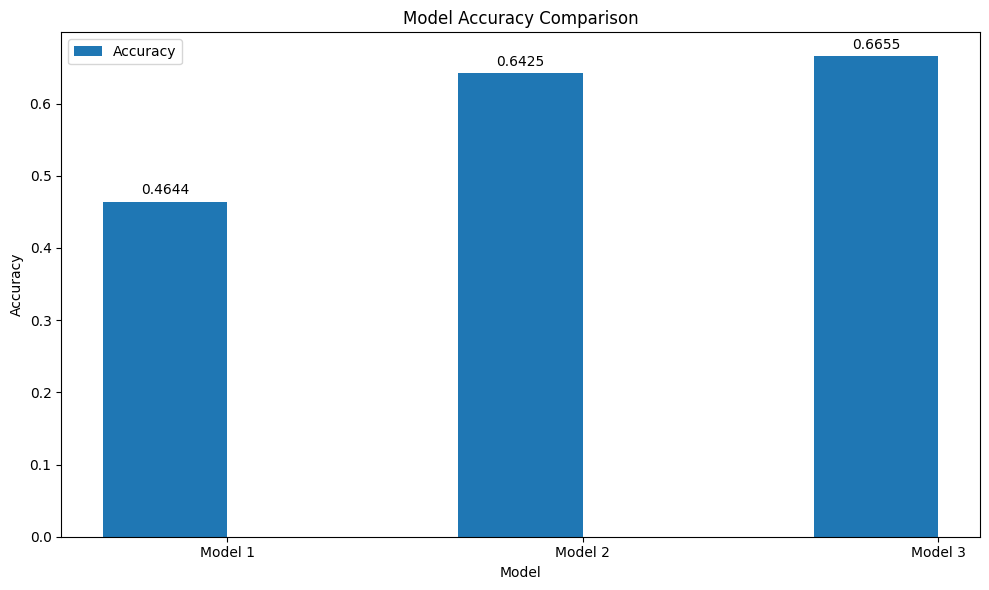

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
models = ['Model 1', 'Model 2', 'Model 3']
accuracy_values = df['Accurcy'].tolist()
loss_values = df['Loss'].tolist()

x = np.arange(len(models)) # Label locations
width = 0.35 # Width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracy_values, width, label='Accuracy')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

ax.bar_label(rects1, padding=3)

fig.tight_layout()
plt.show()

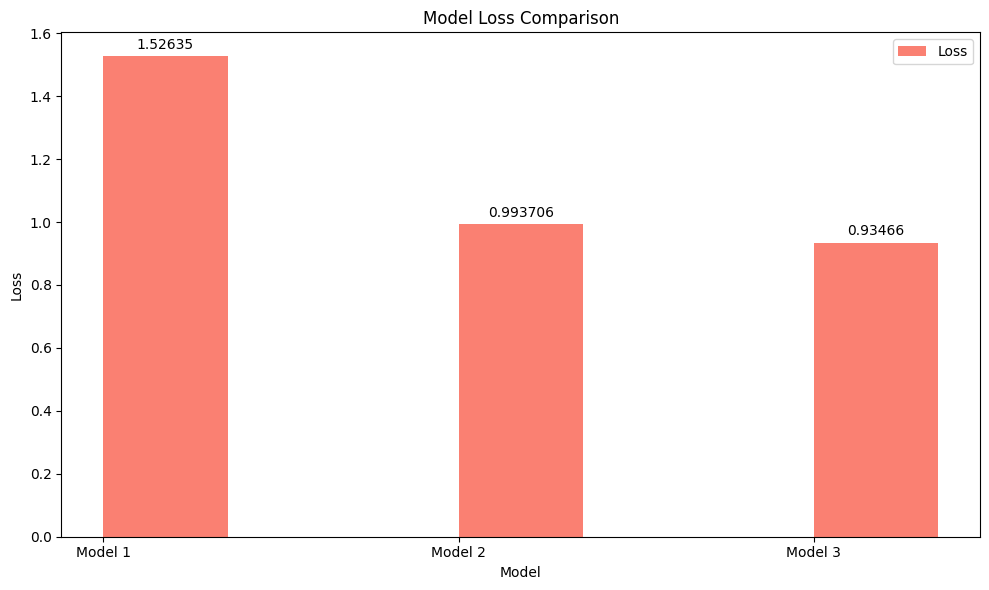

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))
rects2 = ax.bar(x + width/2, loss_values, width, label='Loss', color='salmon')

ax.set_xlabel('Model')
ax.set_ylabel('Loss')
ax.set_title('Model Loss Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

ax.bar_label(rects2, padding=3)

fig.tight_layout()
plt.show()